In [1]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [ ]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

from src.models import create_resnet18_full



DATASET2_DIR = (
    "E:/Work/AI/MAKTAB/HW-CW-S02/FINAL BOSS/"
    "dataset/CROP+MERGED/train"
)

TEST_DIR = (
    "E:/Work/AI/MAKTAB/HW-CW-S02/FINAL BOSS/"
    "dataset/test"
)

MODEL_DIR = (
    "E:/Work/AI/MAKTAB/HW-CW-S02/"
    "Vehicle Classification/Vehicle-Classification-Project/"
    "models/dataset2"
)


MODEL_PATHS = [

    f"{MODEL_DIR}/resnet18_d2_full_1.pth",

    f"{MODEL_DIR}/resnet18_d2_full_2.pth",

    f"{MODEL_DIR}/resnet18_d2_full_best.pth",

    f"{MODEL_DIR}/resnet18_d2_layer4_best.pth",

    f"{MODEL_DIR}/resnet18_d2_fullnormalized.pth"

]


NORMALIZED_MODEL_NAME = (
    "resnet18_d2_fullnormalized.pth"
)


def is_normalized_model(model_path):

    return model_path.split("/")[-1] == NORMALIZED_MODEL_NAME



device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


print("=" * 70)
print("DEVICE")
print("=" * 70)

print(device)

if torch.cuda.is_available():

    print(
        torch.cuda.get_device_name(0)
    )




transform_normal = transforms.Compose([

    transforms.Resize((150, 150)),

    transforms.ToTensor()

])


# Normalized model

transform_normalized = transforms.Compose([

    transforms.Resize((150, 150)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]

    )

])


dataset_normal = datasets.ImageFolder(

    DATASET2_DIR,

    transform=transform_normal

)


dataset_normalized = datasets.ImageFolder(

    DATASET2_DIR,

    transform=transform_normalized

)


assert (

    dataset_normal.class_to_idx
    ==
    dataset_normalized.class_to_idx

), "Class mapping is different!"


assert (

    len(dataset_normal)
    ==
    len(dataset_normalized)

), "Dataset sizes are different!"




indices = list(
    range(len(dataset_normal))
)

labels = dataset_normal.targets


train_indices, val_indices = train_test_split(

    indices,

    test_size=0.2,

    random_state=42,

    stratify=labels

)



val_dataset_normal = Subset(

    dataset_normal,

    val_indices

)


val_dataset_normalized = Subset(

    dataset_normalized,

    val_indices

)


val_loader_normal = DataLoader(

    val_dataset_normal,

    batch_size=32,

    shuffle=False

)


val_loader_normalized = DataLoader(

    val_dataset_normalized,

    batch_size=32,

    shuffle=False

)



def evaluate_model(model, loader):

    model.eval()

    correct = 0

    total = 0


    with torch.no_grad():

        for images, targets in loader:

            images = images.to(device)

            targets = targets.to(device)


            outputs = model(images)


            predictions = outputs.argmax(

                dim=1

            )


            correct += (

                predictions == targets

            ).sum().item()


            total += targets.size(0)


    return correct / total



models = []

val_accuracies = []


print("\n")
print("=" * 70)
print("VALIDATION RESULTS")
print("=" * 70)


for model_path in MODEL_PATHS:

    model_name = model_path.split("/")[-1]


    model = create_resnet18_full(

        num_classes=8

    )


    checkpoint = torch.load(

        model_path,

        map_location=device

    )


    model.load_state_dict(

        checkpoint

    )


    model = model.to(device)


    if is_normalized_model(model_path):

        val_loader = val_loader_normalized

        transform_type = "NORMALIZED"

    else:

        val_loader = val_loader_normal

        transform_type = "NORMAL"


    val_accuracy = evaluate_model(

        model,

        val_loader

    )


    models.append(model)

    val_accuracies.append(

        val_accuracy

    )


    print(

        f"{model_name:<40}"
        f"{transform_type:<15}"
        f"{val_accuracy * 100:.2f}%"

    )



total_accuracy = sum(

    val_accuracies

)


weights = [

    accuracy / total_accuracy

    for accuracy in val_accuracies

]


print("\n")
print("=" * 70)
print("MODEL WEIGHTS")
print("=" * 70)


for model_path, accuracy, weight in zip(

    MODEL_PATHS,

    val_accuracies,

    weights

):

    model_name = model_path.split("/")[-1]


    if is_normalized_model(model_path):

        transform_type = "NORMALIZED"

    else:

        transform_type = "NORMAL"


    print(

        f"{model_name:<40}"
        f"{transform_type:<15}"
        f"Val: {accuracy * 100:.2f}%   "
        f"Weight: {weight:.4f}"

    )


print(

    f"\nSum of weights: "
    f"{sum(weights):.4f}"

)



test_datasets = []


for model_path in MODEL_PATHS:

    if is_normalized_model(model_path):

        test_dataset = datasets.ImageFolder(

            TEST_DIR,

            transform=transform_normalized

        )

    else:

        test_dataset = datasets.ImageFolder(

            TEST_DIR,

            transform=transform_normal

        )


    test_datasets.append(

        test_dataset

    )




for dataset in test_datasets:

    assert (

        dataset.class_to_idx
        ==
        test_datasets[0].class_to_idx

    ), "Test class mapping is different!"


    assert (

        len(dataset)
        ==
        len(test_datasets[0])

    ), "Test dataset sizes are different!"


print("\n")
print("=" * 70)
print("TEST DATASET")
print("=" * 70)


print(

    f"Test images: "
    f"{len(test_datasets[0])}"

)



test_loaders = []


for dataset in test_datasets:

    loader = DataLoader(

        dataset,

        batch_size=32,

        shuffle=False

    )


    test_loaders.append(

        loader

    )



ensemble_probabilities = None

targets_all = None


print("\n")
print("=" * 70)
print("RUNNING WEIGHTED ENSEMBLE")
print("=" * 70)


for index, (
    model,
    weight,
    test_loader,
    model_path
) in enumerate(

    zip(

        models,

        weights,

        test_loaders,

        MODEL_PATHS

    )

):

    model.eval()


    model_name = model_path.split("/")[-1]


    if is_normalized_model(model_path):

        transform_type = "NORMALIZED"

    else:

        transform_type = "NORMAL"


    print(

        f"\nModel {index + 1}: "
        f"{model_name}"

    )

    print(

        f"Transform: "
        f"{transform_type}"

    )

    print(

        f"Weight: "
        f"{weight:.4f}"

    )


    model_probabilities = []

    model_targets = []


    with torch.no_grad():

        for images, targets in test_loader:

            images = images.to(device)


            outputs = model(images)


            probabilities = torch.softmax(

                outputs,

                dim=1

            )


            model_probabilities.append(

                probabilities.cpu()

            )


            model_targets.append(

                targets

            )


    model_probabilities = torch.cat(

        model_probabilities,

        dim=0

    )


    model_targets = torch.cat(

        model_targets,

        dim=0

    )


    print(

        f"Samples: "
        f"{model_probabilities.size(0)}"

    )


    

    if ensemble_probabilities is None:

        ensemble_probabilities = (

            model_probabilities
            *
            weight

        )


        targets_all = model_targets



    else:

        ensemble_probabilities += (

            model_probabilities
            *
            weight

        )



predictions = ensemble_probabilities.argmax(

    dim=1

)



correct = (

    predictions == targets_all

).sum().item()


total = targets_all.size(0)


test_accuracy = correct / total

print("\n")
print("=" * 70)
print("FINAL WEIGHTED ENSEMBLE RESULT")
print("=" * 70)


print(

    f"Correct: "
    f"{correct}/{total}"

)


print(

    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"

)

DEVICE
cuda
NVIDIA GeForce RTX 3060 Laptop GPU


VALIDATION RESULTS
resnet18_d2_full_1.pth                  NORMAL         98.09%
resnet18_d2_full_2.pth                  NORMAL         98.43%
resnet18_d2_full_best.pth               NORMAL         98.20%
resnet18_d2_layer4_best.pth             NORMAL         97.08%
resnet18_d2_fullnormalized.pth          NORMALIZED     97.76%


MODEL WEIGHTS
resnet18_d2_full_1.pth                  NORMAL         Val: 98.09%   Weight: 0.2004
resnet18_d2_full_2.pth                  NORMAL         Val: 98.43%   Weight: 0.2011
resnet18_d2_full_best.pth               NORMAL         Val: 98.20%   Weight: 0.2006
resnet18_d2_layer4_best.pth             NORMAL         Val: 97.08%   Weight: 0.1983
resnet18_d2_fullnormalized.pth          NORMALIZED     Val: 97.76%   Weight: 0.1997

Sum of weights: 1.0000


TEST DATASET
Test images: 400


RUNNING WEIGHTED ENSEMBLE

Model 1: resnet18_d2_full_1.pth
Transform: NORMAL
Weight: 0.2004
Samples: 400

Model 2: resnet18_d2_f

In [ ]:

print("\n")
print("=" * 70)
print("INDIVIDUAL MODEL TEST RESULTS")
print("=" * 70)

individual_test_accuracies = []

for model_path, model, test_loader in zip(
    MODEL_PATHS,
    models,
    test_loaders
):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, targets in test_loader:

            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == targets
            ).sum().item()

            total += targets.size(0)

    test_accuracy = correct / total

    individual_test_accuracies.append(
        test_accuracy
    )

    model_name = model_path.split("/")[-1]

    print(
        f"{model_name:<40}"
        f"Test Accuracy: {test_accuracy * 100:.2f}%"
    )

print("\n")
print("=" * 70)
print("SUMMARY")
print("=" * 70)

for model_path, accuracy in zip(
    MODEL_PATHS,
    individual_test_accuracies
):
    model_name = model_path.split("/")[-1]

    print(
        f"{model_name:<40}"
        f"{accuracy * 100:.2f}%"
    )

best_index = max(
    range(len(individual_test_accuracies)),
    key=individual_test_accuracies.__getitem__
)

print("\n")
print(
    "Best Individual Model:",
    MODEL_PATHS[best_index].split("/")[-1]
)

print(
    f"Best Test Accuracy: "
    f"{individual_test_accuracies[best_index] * 100:.2f}%"
)



INDIVIDUAL MODEL TEST RESULTS
resnet18_d2_full_1.pth                  Test Accuracy: 98.25%
resnet18_d2_full_2.pth                  Test Accuracy: 98.50%
resnet18_d2_full_best.pth               Test Accuracy: 97.75%
resnet18_d2_layer4_best.pth             Test Accuracy: 94.75%
resnet18_d2_fullnormalized.pth          Test Accuracy: 97.50%


SUMMARY
resnet18_d2_full_1.pth                  98.25%
resnet18_d2_full_2.pth                  98.50%
resnet18_d2_full_best.pth               97.75%
resnet18_d2_layer4_best.pth             94.75%
resnet18_d2_fullnormalized.pth          97.50%


Best Individual Model: resnet18_d2_full_2.pth
Best Test Accuracy: 98.50%


Total wrong: 6
Actual: ambulance | Predicted: vanet | Confidence: 50.58%


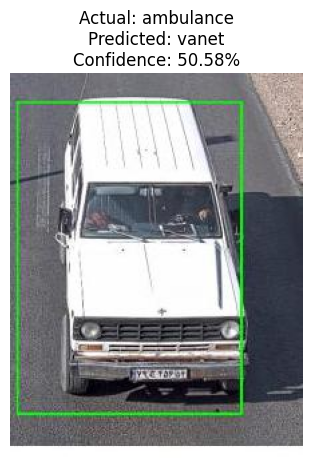

Actual: kamyun | Predicted: kamyunet | Confidence: 57.62%


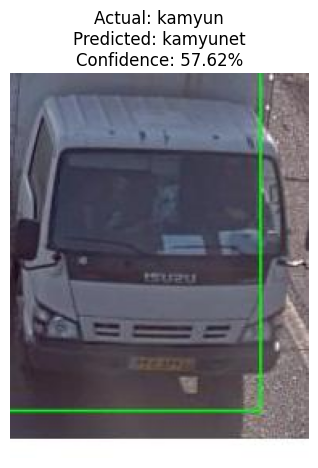

Actual: kamyun | Predicted: kamyunet | Confidence: 77.28%


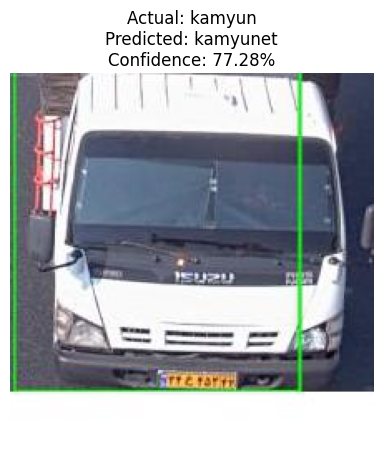

Actual: kamyun | Predicted: kamyunet | Confidence: 98.90%


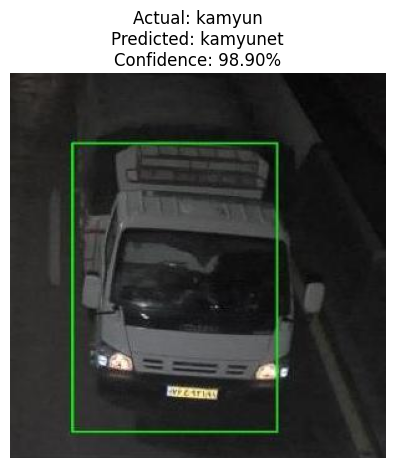

Actual: kamyun | Predicted: minibus | Confidence: 50.29%


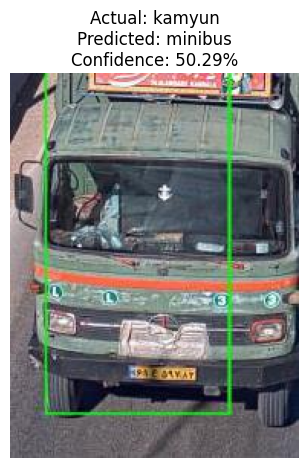

Actual: kamyunet | Predicted: kamyun | Confidence: 60.13%


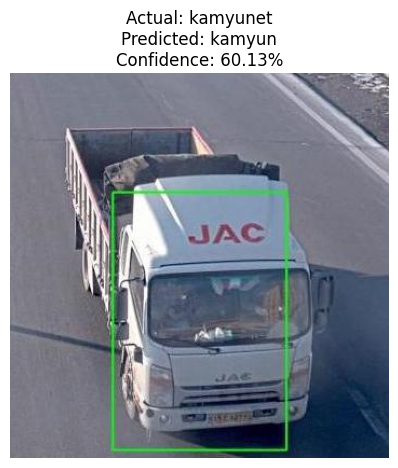

In [12]:


wrong_predictions = []

for i in range(len(targets_all)):
    if predictions[i] != targets_all[i]:
        wrong_predictions.append({
            "path": test_datasets[0].samples[i][0],
            "actual": test_datasets[0].classes[targets_all[i].item()],
            "predicted": test_datasets[0].classes[predictions[i].item()],
            "confidence": ensemble_probabilities[i].max().item()
        })

print("Total wrong:", len(wrong_predictions))

for item in wrong_predictions:
    print(
        f"Actual: {item['actual']} | "
        f"Predicted: {item['predicted']} | "
        f"Confidence: {item['confidence'] * 100:.2f}%"
    )

    image = Image.open(item["path"]).convert("RGB")

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(
        f"Actual: {item['actual']}\n"
        f"Predicted: {item['predicted']}\n"
        f"Confidence: {item['confidence'] * 100:.2f}%"
    )
    plt.axis("off")
    plt.show()

In [29]:


DATASET3_DIR = (
    "E:/Work/AI/MAKTAB/HW-CW-S02/"
    "FINAL BOSS/dataset/CROP+MERGED - Copy/train"
)

TEST_DIR = (
    "E:/Work/AI/MAKTAB/HW-CW-S02/"
    "FINAL BOSS/dataset/test"
)

MODEL_PATH = (
    "E:/Work/AI/MAKTAB/HW-CW-S02/"
    "Vehicle Classification/Vehicle-Classification-Project/"
    "models/dataset3/resnet18_d3_full_best.pth"
)


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])


train_dataset = datasets.ImageFolder(
    DATASET3_DIR,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=transform
)


print("Classes:", train_dataset.classes)
print("Test images:", len(test_dataset))


model = create_resnet18_full(
    num_classes=8
)

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()


test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


correct = 0
total = 0


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += len(labels)


accuracy = correct / total


print(f"Correct: {correct}/{total}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Classes: ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
Test images: 400
Correct: 383/400
Test Accuracy: 95.75%


In [30]:

MODEL_PATH = (
    "E:/Work/AI/MAKTAB/HW-CW-S02/"
    "Vehicle Classification/Vehicle-Classification-Project/"
    "models/dataset3/resnet18_d3_full_best.pth"
)

NISSAN_DIR = "C:/Users/Amir/Videos/ney"

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])

model = create_resnet18_full(num_classes=8)

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()

classes = test_dataset.classes

files = [
    os.path.join(NISSAN_DIR, f)
    for f in os.listdir(NISSAN_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

confidences = []

with torch.no_grad():

    for path in files:

        image = Image.open(path).convert("RGB")

        x = transform(image).unsqueeze(0).to(device)

        output = model(x)

        probability = torch.softmax(output, dim=1)

        confidence = probability.max().item()

        confidences.append(confidence)


threshold = np.percentile(
    confidences,
    5
)

print(f"Images: {len(files)}")
print(f"Threshold: {threshold * 100:.2f}%")

Images: 202
Threshold: 46.78%


In [32]:

NEW_DIR = "C:/Users/Amir/Videos/neysan"

files = [
    os.path.join(NEW_DIR, f)
    for f in os.listdir(NEW_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

unknown = 0
known = 0

model.eval()

with torch.no_grad():

    for path in files:

        image = Image.open(path).convert("RGB")

        x = transform(image).unsqueeze(0).to(device)

        output = model(x)

        probability = torch.softmax(
            output,
            dim=1
        )

        confidence, prediction = probability.max(dim=1)

        confidence = confidence.item()
        prediction = prediction.item()

        if confidence < threshold:
            label = "Unknown"
            unknown += 1
        else:
            label = classes[prediction]
            known += 1

        
       

print()
print(f"Total: {len(files)}")
print(f"Known: {known}")
print(f"Unknown: {unknown}")
print(
    f"Unknown percentage: "
    f"{unknown / len(files) * 100:.2f}%"
)


Total: 216
Known: 211
Unknown: 5
Unknown percentage: 2.31%
